# Project Part 5 — Grade Performance Analysis

## Dataset Overview
This project analyzes grade data from two Spring 2026 courses: UI/UX Design and Data Science. Each record represents a single assignment and captures key metadata about submission timing and performance.

### Columns:
1. **Name** — Assignment name
2. **Category** — Assignment type (e.g., quiz, exam, participation)
3. **Due** — Due date
4. **Submitted** — Submission timestamp
5. **Score** — Points earned
6. **OutOf** — Maximum possible points
7. **CleanCategory** — Standardized category used for analysis (quizzes, exams/tests, small assignments, big assignments)

# Load and Clean Data
Raw grade data is loaded from a CSV, numeric columns are coerced, and a `Percent` column is derived. A standardized `CleanCategory` column is also added to normalize the varied category labels from Canvas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsProjectData import clean_category
df = pd.read_csv('projectData.csv')

df["CleanCategory"] = df.apply(clean_category, axis=1)

df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df["OutOf"] = pd.to_numeric(df["OutOf"], errors="coerce")
df["Percent"] = (df["Score"] / df["OutOf"]) * 100


df.to_csv("cleaned_grades.csv", index=False)

plt.style.use('seaborn-v0_8-whitegrid')

## Cleaning Notes
The data was already fairly clean coming in:
- Grade data was copy-pasted from Canvas and formatted into CSV using ChatGPT, then manually cleaned
- Assignment categories were standardized into four groups: quizzes, exams/tests, small assignments, and big assignments
- All other columns were usable as-is



## Join — Day of Week and Days Early
To enrich the dataset, two new columns are derived from the existing date fields:
- **DayOfWeek** — the day of the week each assignment was due, extracted from `Due`
- **DaysEarly** — how many days before the deadline the assignment was submitted (negative values indicate late submissions)

This constitutes a logical join with a "day-of-week" dimension, allowing us to explore whether submission timing or due-date patterns correlate with performance.

In [2]:
from datetime import datetime

def parse_date(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    for fmt in ["%b %d %I:%M%p", "%b %d %I:%M %p"]:
        try:
            return datetime.strptime(f"{s} 2026", fmt + " %Y")
        except:
            pass
    return None

df["DueDate"] = df["Due"].apply(parse_date)
df["SubDate"] = df["Submitted"].apply(parse_date)

# Join: day of week from due date
df["DayOfWeek"] = df["DueDate"].apply(lambda x: x.strftime("%A") if pd.notna(x) else None)

# Days submitted early (negative = late)
df["DaysEarly"] = (df["DueDate"] - df["SubDate"]).apply(
    lambda x: x.days if pd.notna(x) else None
)

## Boxplot — Grade Distribution by Category
This boxplot shows the spread of grades across each assignment category. It helps identify which categories tend to have more consistent performance and which have more variance.

<Figure size 640x480 with 0 Axes>

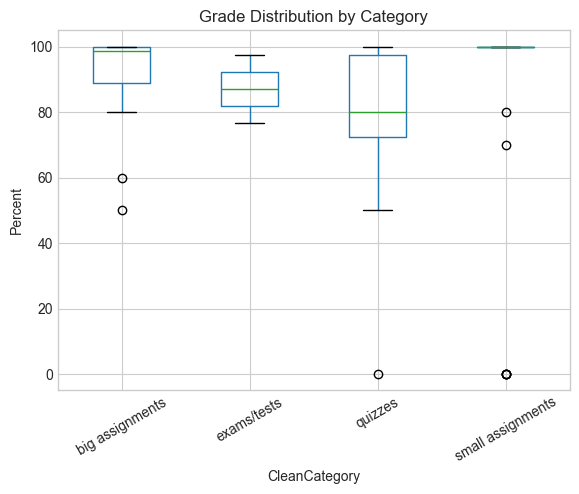

In [3]:
plt.figure()
graded = df.dropna(subset=["Score", "OutOf"])
graded.boxplot(column="Percent", by="CleanCategory")

plt.ylabel("Percent")
plt.title("Grade Distribution by Category")
plt.suptitle("")
plt.xticks(rotation=30)
plt.show()

## Bar Chart — Average Grade by Category
This bar chart shows the mean percentage score for each assignment category. It complements the boxplot by giving a single summary value per category, making cross-category comparisons easier.

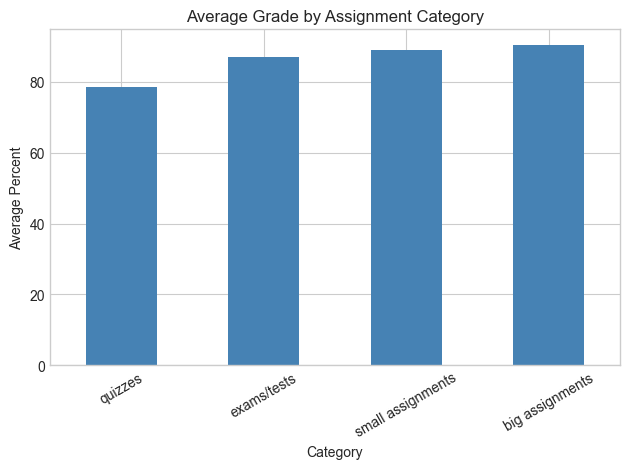

In [4]:

avg_by_cat = graded.groupby("CleanCategory")["Percent"].mean().sort_values()

plt.figure()
avg_by_cat.plot(kind="bar", color="steelblue")
plt.title("Average Grade by Assignment Category")
plt.ylabel("Average Percent")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Hypothesis Test — Is My Average Grade Above 80%?

**H₀:** Mean grade ≤ 80%  
**H₁:** Mean grade > 80%

A one-sample t-test is used to test whether the average grade across all assignments is statistically significantly above 80%. A p-value below 0.05 leads us to reject the null hypothesis.

In [5]:
from scipy import stats

## Hypothesis Test: Is my average grade significantly above 80%?
# H0: mean percent <= 80
# H1: mean percent > 80

sample = graded["Percent"].dropna()
t_stat, p_value = stats.ttest_1samp(sample, popmean=80, alternative="greater")

print(f"Sample mean: {sample.mean():.2f}%")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Evidence that mean grade is significantly above 80%")
else:
    print("Fail to reject H0")

Sample mean: 86.24%
t-statistic: 2.1338
p-value: 0.0180
Reject H0: Evidence that mean grade is significantly above 80%


## Machine Learning Setup
A binary target variable (`HighScore`) is created, where 1 indicates a score ≥ 85% and 0 indicates below. Four features are used:
- **CategoryEncoded** — numerically encoded assignment category
- **DayEncoded** — numerically encoded day of the week the assignment was due
- **DaysEarly** — how early (or late) the assignment was submitted
- **OutOf** — the total point value of the assignment

The dataset is split 80/20 into training and test sets.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ml_df = df.dropna(subset=["Percent", "DayOfWeek", "DaysEarly", "OutOf", "CleanCategory"]).copy()

ml_df["HighScore"] = (ml_df["Percent"] >= 85).astype(int)

le_cat = LabelEncoder()
le_day = LabelEncoder()
ml_df["CategoryEncoded"] = le_cat.fit_transform(ml_df["CleanCategory"])
ml_df["DayEncoded"] = le_day.fit_transform(ml_df["DayOfWeek"])

features = ["CategoryEncoded", "DayEncoded", "DaysEarly", "OutOf"]
X = ml_df[features]
y = ml_df["HighScore"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Chart — Average Grade by Day of Week (Due Date)
This bar chart explores whether assignments due on certain days of the week tend to correlate with higher or lower scores. Note that this is observational — with a small dataset, any patterns may not generalize.

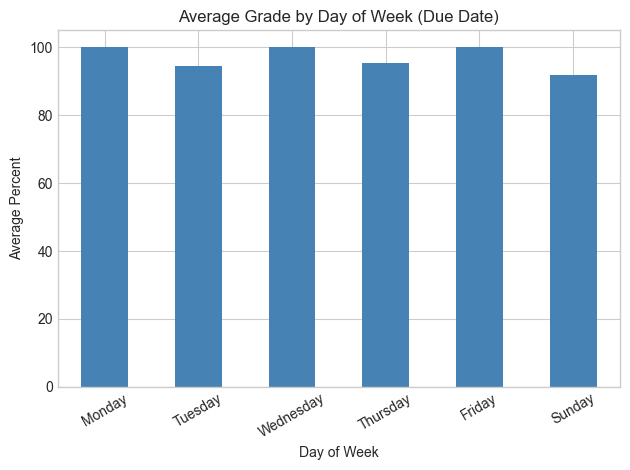

In [7]:
avg_by_day = ml_df.groupby("DayOfWeek")["Percent"].mean()

# Order days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_day = avg_by_day.reindex([d for d in day_order if d in avg_by_day.index])

plt.figure()
avg_by_day.plot(kind="bar", color="steelblue")
plt.title("Average Grade by Day of Week (Due Date)")
plt.ylabel("Average Percent")
plt.xlabel("Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## K-Nearest Neighbors (KNN) Classifier
A KNN classifier with k=5 is trained to predict whether a given assignment will result in a high score (≥ 85%). Results are evaluated using precision, recall, and F1-score.

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Results:")
print(classification_report(y_test, y_pred_knn))

KNN Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.91      1.00      0.95        10

    accuracy                           0.91        11
   macro avg       0.45      0.50      0.48        11
weighted avg       0.83      0.91      0.87        11



c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Decision Tree Classifier
A decision tree with a max depth of 4 is trained on the same features and target. The tree is visualized below. Results are compared against KNN.

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.91      1.00      0.95        10

    accuracy                           0.91        11
   macro avg       0.45      0.50      0.48        11
weighted avg       0.83      0.91      0.87        11



c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ashke\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

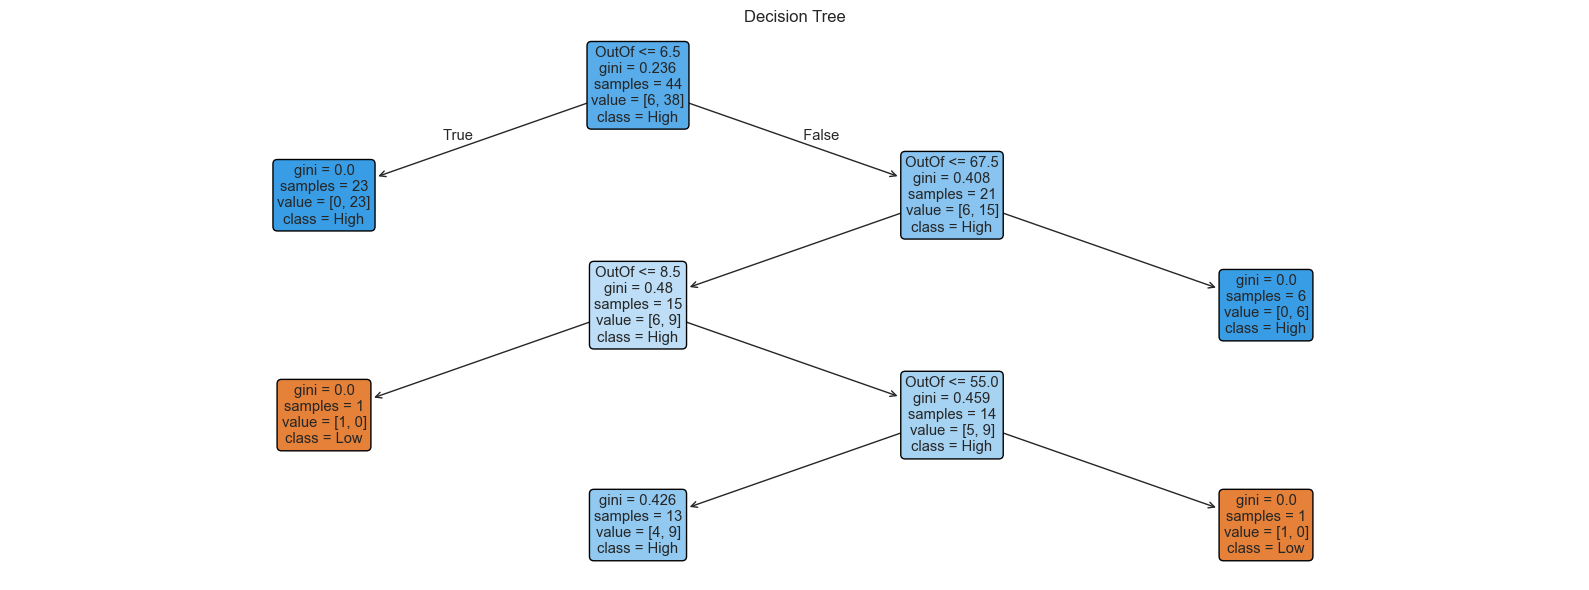

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(16, 6))
plot_tree(dt, feature_names=features,
          class_names=["Low", "High"],
          filled=True, rounded=True)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

## Conclusions

- **Dataset size was a major limitation.** Only two courses had assignments in a format compatible with this analysis, resulting in a very small dataset (~92 rows total, far fewer after filtering for graded and fully-dated assignments).
- **Both models (KNN and Decision Tree) achieved the same 0.91 accuracy** — but this is misleading. With only 11 test samples and 10 of them being high-score (class 1), both models simply predicted "high score" for everything and still scored well. Neither actually learned meaningful patterns.
- **Class imbalance** — because the vast majority of grades are above 85%, the binary target is heavily skewed toward class 1. A threshold of 70% might produce a more balanced split and give the models something real to learn.
- **The underlying ideas are sound.** Using submission timing, assignment type, and due-date day as predictors for grade performance is a reasonable hypothesis — the dataset just wasn't large enough to validate it. With more data across more courses and semesters, these models could potentially surface real patterns.